<div style="background:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:20px 24px;
            direction:ltr; text-align:left;">

  <h2 style="margin:4px 0 14px 0; font-size:48px; font-weight:700; color:#004c70;">
    Regression Course
  </h2>

  <div style="height:1px; background:#cbeafb; margin:4px 0 18px 0;"></div>

  <div style="font-size:26px; color:#0a5773; font-weight:600; margin:0 0 10px 0;">
    Transformations
  </div>

  <span style="display:inline-block; font-size:18px; font-weight:600; color:#0a5773;
               background:#d9effc; border:1px solid #86c4e8; border-radius:999px; padding:6px 12px;">
    Exercise no. 2
  </span>

</div>


<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:18px 22px; direction:ltr;">


  <h3 style="text-align:left; color:#0a5773; font-size:30px; font-weight:600; margin:0;">
    Quick Review of the Previous Lesson
  </h3>

</div>


<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:-1px 0px;">

<div <h3 style="text-align:left; color:#0a5773; font-size:30px; font-weight:600; margin:0;">

Regression equation.
</div>

<div style=font-size:250%; ">

 $$ y_i = b_0+b_1 x_i +\epsilon_i $$
 
  <div style="height:1px; background:#cbeafb; margin:0 0 18px 0;"></div>
</div>

<div dir="rtl">  
    
###    $y_i$: המשתנה המוסבר (תוצאה, יעד)
### $x_i$: המשתנה התלוי, המסביר (גורם משפיע)
### $b_0$: חותך של המשוואה הליניארית
### $b_1$: השיפוע של המשוואה הליניארית, כמה משתנה $y$ בממוצע לכל עלייה של יחידה אחת ב- $x$
### $\epsilon_i$: השגיאה ה$i$ , כל הגורמים ש- $x$ לא מסביר.
    
### הנחה היא שיש קשר ליניארי בין x ל-y. אבל הוא לא מושלם, ישנה איזושהי שגיאה המתארת בין המציאות לקו הליניארי.

<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:-1px 0px;">

  
<div <h3 style="text-align:left; color:#0a5773; font-size:30px; font-weight:600; margin:0;">

OLS – Ordinary Least Squares
</div>
<div style=font-size:250%; ">

$$ min_{b_0,b_1}:  \sum_{i=1}^n (\hat{y}_i-y_i)^2 $$

 <div style="height:1px; background:#cbeafb; margin:0 0 18px 0;"></div>
</div>

<div dir="rtl">  

### המטרה הייתה למצוא קו שמקטין את סך הריבועים של השגיאות
### כלומר אנחנו מחפשים את הקו שהנקודות שלו הכי קרובות לנקודות האמיתיות בממוצע.

<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:-1px 0px;">


<div style=font-size:250%; ">
    
 $$R^2 = \frac{SST-SSR}{SST}$$ 
<div dir="rtl">

##### 
#### כאשר:
###### כמה הצלחנו להסביר את המרחקים מהממוצע
</div>

 $$SSR = \sum_{i=1}^{n}(y_i-\hat{y_i})^2$$
<div dir="rtl">

###### סכום ריבועי המרחקים מהממוצע 
</div>

  $$SST= \sum_{i=1}^{n}(y_i-\bar{y})^2$$

   <div style="height:1px; background:#cbeafb; margin:0 0 18px 0;"></div>
</div>

<div dir="rtl"> 

### מדד \\(R^2\\) בוחן כמה טוב המודל מסביר את השונות של הנתונים.

<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:18px 22px; direction:ltr;">


  <h3 style="text-align:left; color:#0a5773; font-size:30px; font-weight:600; margin:0;">
    What We’ll Talk About Today
  </h3>

</div>


<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:18px 22px; direction:ltr;">

<div dir="rtl">  

## מוטיבציה : מה קורה כשהמודל ליניארי לא מתאים ?
### לפעמים הקשר בין משתנים **לא ליניארי** ובמקרים כאלה הקו הישר לא מצליח לתפוס את הדפוס וזה גורם למצב שהשגיאות שיטתיות והשאריות לא מקריות ובנוסף מדד טיב ההתאמה גם יורד

### איך נוכל "ליישר" קשרים לא ליניאריים?
### כאן נכנסות הטרנספורמציות, המטרה שלהן היא להפוך את קשר לא ליניארי שאפשר לאמוד בעזרת OLS. (שכולכם אוהבים)
### המודל ליניארי במרחב המותמר, אבל לא בהכרח ליניארי במרחב הנתונים המקורי.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
# from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import pickle as pkl
from tqdm import tqdm

## שאלת כיתה - המכונה המתחממת 

<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:20px 20px;">

<div dir="rtl">

### במפעל לייצור רכיבים חשמליים, ישנה מכונה. 
### כאשר המכונה עובדת יותר מדי זמן ברציפות היא מתחממת ובמקרה כזה היא עלולה להתקלקל ואף להוות סכנה של פיצוץ ופגיעה בעובדים. <br> מהנדס הבטיחות בחברה אסף נתונים של 60 זמני עבודה שונים של המכונה 0 עד 30 שעות (ראו משתנה x_vals) במרווחים קבועים ואת הטמפרטורה התואמת של המכונה (ראה משתנה y_vals_trans_1 שמושך את הנתונים מתוך הקובץ y_vals_trans_1_tirgul.pkl).

In [2]:
# num_points = 60
# x_vals = np.linspace(0,30,num_points)
# a, b = 2280, 370
# y_vals_trans_1 = (a+b*x_vals + np.random.normal(0,155,num_points))**0.36
# pkl.dump(y_vals_trans_1, open('../pkl/y_vals_trans_1_tirgul.pkl', 'wb'))

In [3]:
num_points = 60
x_vals = np.linspace(0,30,num_points)
y_vals_trans_1 = pkl.load(open('pkl/y_vals_trans_1_tirgul.pkl', 'rb'))

In [4]:
df_data = pd.DataFrame({'x_vals__working_time': x_vals, 'y_vals_trans_1__tmp': y_vals_trans_1})
df_data.head()

,x_vals__working_time,y_vals_trans_1__tmp
0,0.000000,16.074597
1,0.508475,16.650095
2,1.016949,17.194873
3,1.525424,17.442153
4,2.033898,17.470289


### מטלות

<div style="background-color:#e0f4ff; border:2px solid #0077b6; border-radius:12px; padding:20px 20px;">

<div dir="rtl">
    
### הציגו גרף פיזור של הטמפרטורה (y_vals_trans_1) כתלות בזמן העבודה של המכונה (x_vals). בנו מודל רגרסיה לינארית לניבוי הטמפרטורה באמצעות זמן העבודה של המכונה. בצעו טרנספורמציה של Ln ושל שורש למשתנה ה Y ובידקו האם קיבלתם מודלים טוב יותר

#### גרף פיזור ללא טרנספורמציה

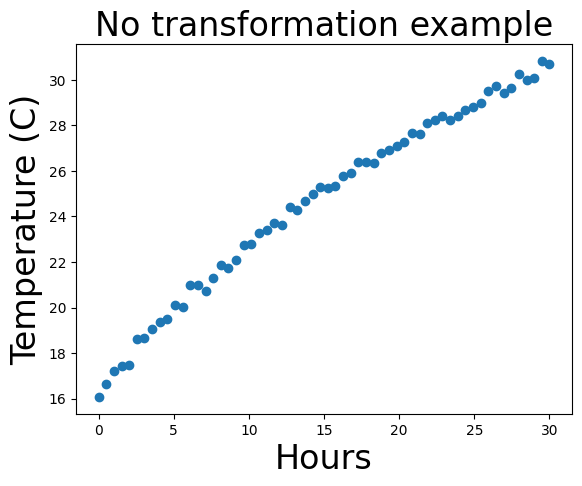

In [5]:
plt.figure()
plt.title('No transformation example', fontsize= 24)
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.scatter(x_vals, y_vals_trans_1)
plt.show()

#### רגרסיה לינארית ללא טרנספורמציה

In [6]:
# Assuming X_train and y_train are your training data
x_vals1 = sm.add_constant(x_vals)  # Add a constant (intercept) term to the features
## If we don't add it, the intercept will be 0.
# Create a linear regression model
model = sm.OLS(y_vals_trans_1, x_vals1)
# Fit the model
results = model.fit()
# Print summary statistics, including p-values for each coefficient
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     2931.
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           2.36e-51
Time:                        16:57:50   Log-Likelihood:                -51.816
No. Observations:                  60   AIC:                             107.6
Df Residuals:                      58   BIC:                             111.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.6476      0.149    118.564      0.0

#### גרף פיזור ללא טרנספורמציה עם קו הקגרסיה בצבע אדום

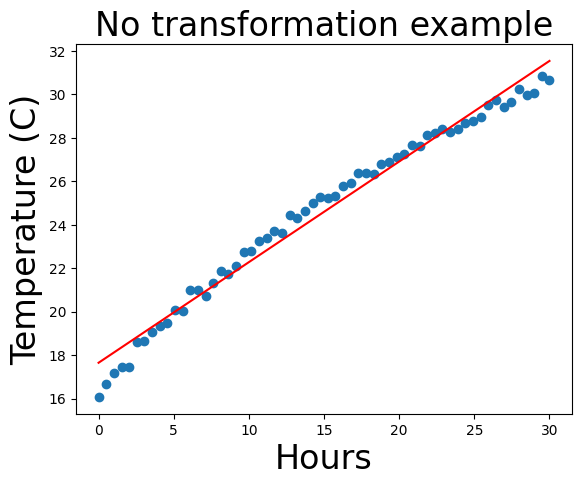

In [7]:
plt.figure()
plt.title('No transformation example', fontsize= 24)
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.scatter(x_vals, y_vals_trans_1)
plt.plot(x_vals, results.predict(x_vals1), color = 'red')
plt.show()

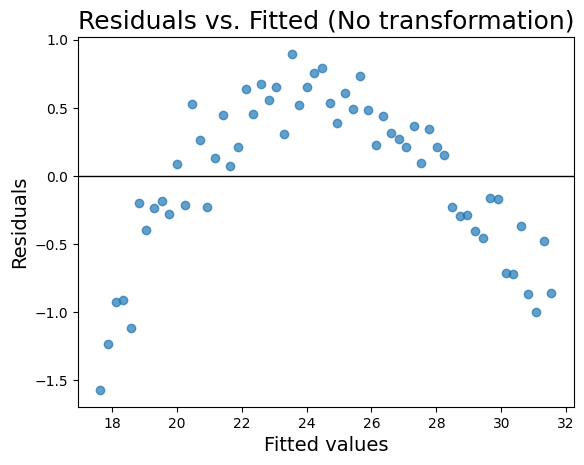

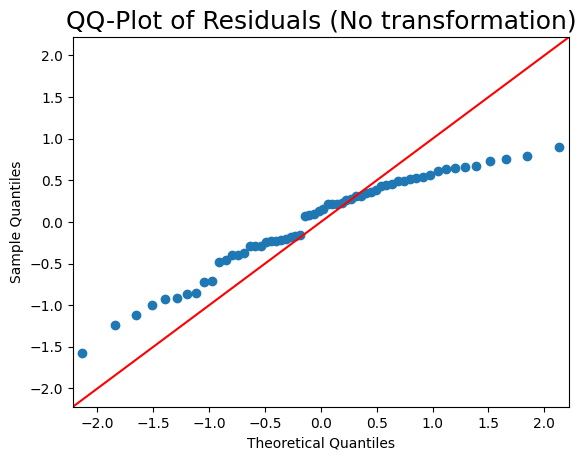

In [8]:
# Residual diagnostics for the no-transformation model
y_hat = results.predict(x_vals1)
residuals = y_vals_trans_1 - y_hat

plt.figure()
plt.title('Residuals vs. Fitted (No transformation)', fontsize=18)
plt.xlabel('Fitted values', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.scatter(y_hat, residuals, alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.show()

import statsmodels.api as sm
sm.qqplot(residuals, line='45')
plt.title('QQ-Plot of Residuals (No transformation)', fontsize=18)
plt.show()


<div dir="rtl">
    
### אם רואים צורה “קשתית”/“משפך” בגרף השאריות - יש רמז לחוסר ליניאריות
### QQ-Plot: סטיות חזקות מהקו = שאריות לא נורמליות

## Transforming the data

<div dir="rtl">  במקום להשתמש בערכים האמיתיים של המשתנה המוסבר ננסה לעשות איזשהו טרנספורמציה ואולי נצליח לעשות למצוא קשר יותר ליניארי. להלן מספר טרנספורמציות אפשריות.

1. $Ln(Y)$ or $Log(Y)$
2. $Exp(Y)$
3. $Y^{0.5}$
4. $Y^2$

The model is:

$$ Ln(\hat{Y}) = b_0 + b_1 X_1 $$

Or,

$$ \hat{Y} = Exp(b_0 + b_1 X_1) $$

<div dir="rtl"> נתחיל עם טרנספורמציה של Ln.

### Log-transform

In [9]:
# lN tRANSFORMATION FOR Y
log_Y_trans_1 = np.log(y_vals_trans_1)

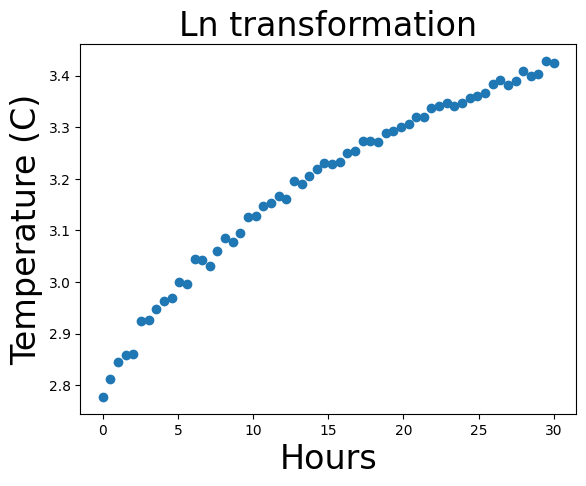

In [10]:
plt.figure()
plt.title('Ln transformation', fontsize= 24)
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.scatter(x_vals, log_Y_trans_1)
plt.show()

In [11]:
# Assuming X_train and y_train are your training data
x_vals1 = sm.add_constant(x_vals)  # Add a constant (intercept) term to the features
## If we don't add it, the intercept will be 0.
# Create a linear regression model
model_trans1 = sm.OLS(log_Y_trans_1, x_vals1)
# Fit the model
results_trans1 = model_trans1.fit()
# Print summary statistics, including p-values for each coefficient
print(results_trans1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     1167.
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           4.11e-40
Time:                        16:57:51   Log-Likelihood:                 110.35
No. Observations:                  60   AIC:                            -216.7
Df Residuals:                      58   BIC:                            -212.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8937      0.010    290.083      0.0

<div dir="rtl"> אפשר לראות שעכשיו המדד של $R^2$  0.953 קטן יותר ופחות טוב מהמודל המקורי

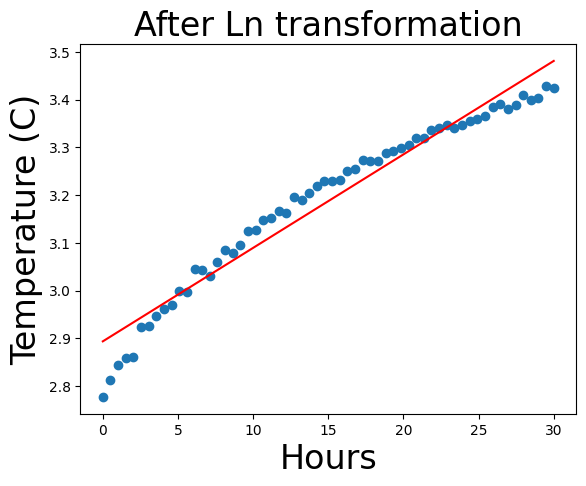

In [12]:
plt.figure()
plt.title('After Ln transformation', fontsize= 24)
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.scatter(x_vals, log_Y_trans_1)
plt.plot(x_vals, results_trans1.predict(x_vals1), color = 'red')
plt.show()

### Square-root transform

<div dir="rtl"> מה היה קורה אילו היינו עושים טרנספורמציה אחרת?
ננסה לעשות עכשיו טרנספורמצית שורש, כלומר:

$$ \sqrt{y} = b_0 +b_1 X_1$$

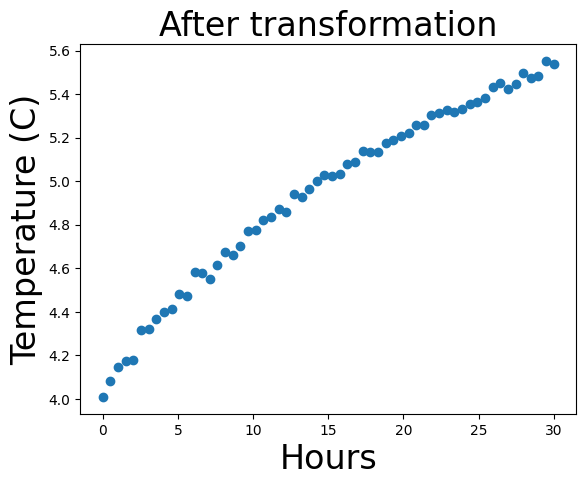

In [13]:
sqrt_Y_trans_1 = y_vals_trans_1**0.5
plt.figure()
plt.title('After transformation', fontsize= 24)
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.scatter(x_vals, sqrt_Y_trans_1)
plt.show()

In [14]:
# Create a linear regression model
model_trans2 = sm.OLS(sqrt_Y_trans_1, x_vals1)
# Fit the model
results_trans2 = model_trans2.fit()
# Print summary statistics, including p-values for each coefficient
print(results_trans2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     1774.
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.45e-45
Time:                        16:57:54   Log-Likelihood:                 69.765
No. Observations:                  60   AIC:                            -135.5
Df Residuals:                      58   BIC:                            -131.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2285      0.020    215.521      0.0

# מציאת טרנספורמציית שורש אופטימלית

<div dir="rtl"> אפשר לראות שעכשיו המדד של $R^2$  0.968 קטן יותר ופחות טוב מהמודל המקורי אבל יותר טוב מטרנספורמציה לן

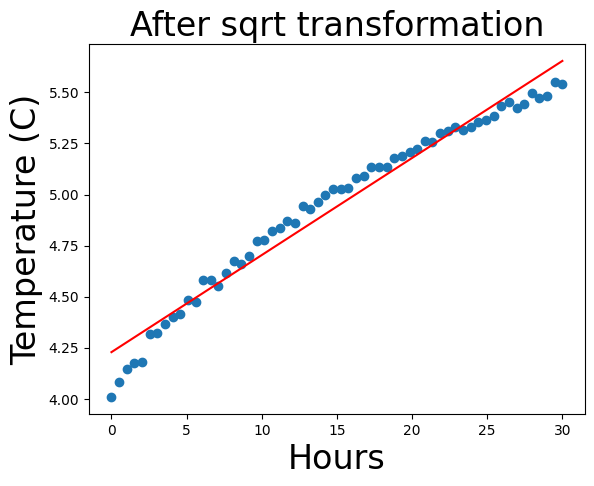

In [15]:
plt.figure()
plt.title('After sqrt transformation', fontsize= 24)
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.scatter(x_vals, sqrt_Y_trans_1)
plt.plot(x_vals, results_trans2.predict(x_vals1), color = 'red')
plt.show()

<div dir="rtl"> ננסה למצוא את ההתמרה של הנתונים בצורה יותר שיטתית. נעשה התמרה מהסוג:
$$ \hat{Y^n} = b_0 +b_1 X_1 $$
כאשר $n$ הוא ערך משתנה בטווח [0.1,10].

In [16]:
results_trans2.rsquared

np.float64(0.9683459233948839)

In [34]:
df_transforms = pd.DataFrame([])

num_trials = 100
for n in tqdm(np.linspace(0.1, 10, num_trials)):
    
    n_Y_trans_n = y_vals_trans_1**n
    # Create a linear regression model
    model_trans_n = sm.OLS(n_Y_trans_n, x_vals1)
    # Fit the model
    results_trans_n = model_trans_n.fit()

    current_R2 = results_trans_n.rsquared

    df_curr = {'n': [n], 'R2': [current_R2]}
    
    # df_transforms = df_transforms.append(df_curr, ignore_index = True)
    df_transforms = pd.concat([df_transforms, pd.DataFrame(df_curr)])
    

100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2635.92it/s]


In [35]:
df_transforms.sort_values('R2', ascending = False).head()

,n,R2
0,2.7,0.997492
0,2.6,0.997477
0,2.8,0.997395
0,2.5,0.997350
0,2.9,0.997190


<div dir="rtl"> בואו נראה את זה ויזואלית:

In [39]:
df_transforms = df_transforms.sort_values('R2', ascending=False).reset_index(drop=True)
df_transforms.head()

,n,R2
0,2.7,0.997492
1,2.6,0.997477
2,2.8,0.997395
3,2.5,0.997350
4,2.9,0.997190


In [40]:
ind = 0

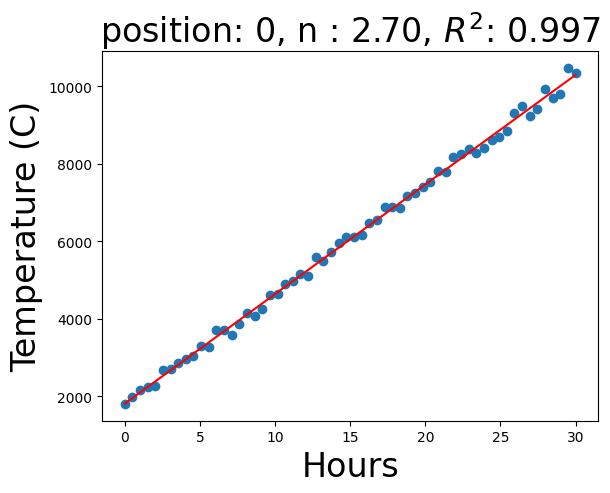

In [41]:
n_Y_trans_n = y_vals_trans_1**df_transforms.loc[ind, 'n']

curr_model =  sm.OLS(n_Y_trans_n, x_vals1)
    # Fit the model
curr_results_trans_n = curr_model.fit()


plt.figure()
plt.title('position: {}, n : {}, $R^2$: {}' .format(ind, "{:.2f}".format(df_transforms.loc[ind, 'n']), "{:.3f}".format(df_transforms.loc[ind, 'R2'])), fontsize = 24)
plt.scatter(x_vals, n_Y_trans_n)
plt.plot(x_vals, curr_results_trans_n.predict(x_vals1), color = 'red')
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.show()
ind += 5

<div dir="rtl"> לפי התוצאות נראה ש$n=2.7$ נותן את התוצאות הטובות ביותר.  בואו נראה איך המשוואה האמיתית נראית. בשביל לעשות את זה נעשה את הפעולה ההפוכה של חזקת n.

1. $\hat{Y}^n = b_o + b_1*X_1$
2. $\hat{Y} = (b_o + b_1*X_1)^{1/n}$

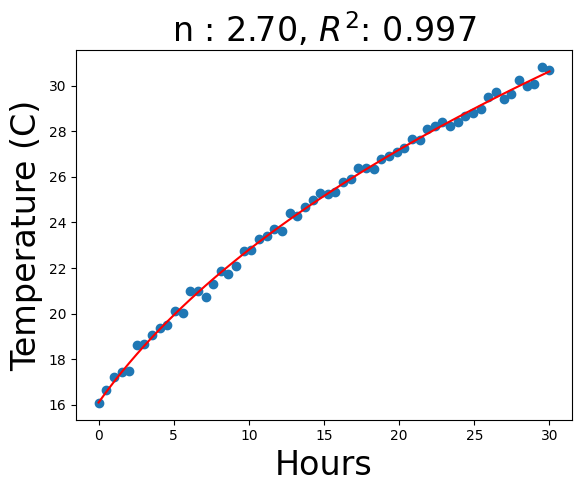

In [42]:
ind = 0
n_Y_trans_n = y_vals_trans_1**df_transforms.loc[ind, 'n']

curr_model =  sm.OLS(n_Y_trans_n, x_vals1)
    # Fit the model
curr_results_trans_n = curr_model.fit()

plt.figure()
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.title('n : {}, $R^2$: {}' .format( "{:.2f}".format(df_transforms.loc[ind, 'n']), "{:.3f}".format(df_transforms.loc[ind, 'R2'])), fontsize = 24)
plt.scatter(x_vals, y_vals_trans_1)
plt.plot(x_vals, curr_results_trans_n.predict(x_vals1)**(1/df_transforms.loc[ind, 'n']), color = 'red')

# מציאת זמן עבודה של מצב מסוכן  (22 מעלות) ושל מצב מסוכן מאוד (26 מעלות)

<div dir="rtl"> נניח כי בין 22  ל-26 מעלות של המכונה זה נחשב למסוכן ומ-26 מעלות זה נחשב למסוכן מאד, מכמה שעות המכונה תהיה לראשונה במצב מסוכן? ומכמה תהיה לראשונה במצב מסוכן מאד?

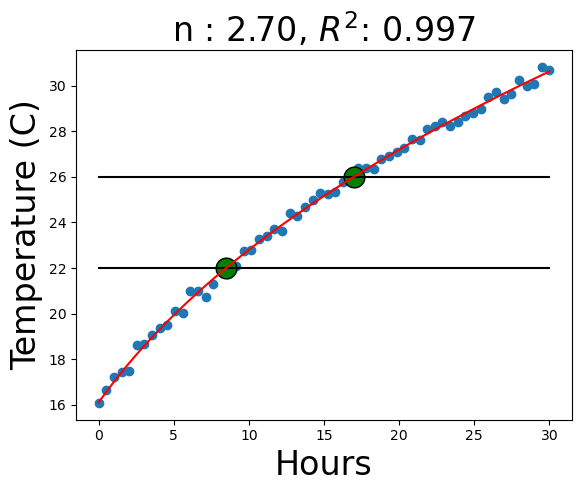

In [20]:
plt.figure()
plt.xlabel('Hours', fontsize= 24)
plt.ylabel('Temperature (C)', fontsize= 24)
plt.title('n : {}, $R^2$: {}' .format( "{:.2f}".format(df_transforms.loc[ind, 'n']), "{:.3f}".format(df_transforms.loc[ind, 'R2'])), fontsize = 24)
plt.scatter(x_vals, y_vals_trans_1)
plt.plot(x_vals, 22*np.ones(x_vals.shape[0]), color = 'black')
plt.plot(x_vals, 26*np.ones(x_vals.shape[0]), color = 'black')
plt.scatter(8.489717304580065, 22, color = 'green', s=222, edgecolors= "black")
plt.scatter(16.976504191751605, 26, color = 'green', s=222, edgecolors= "black")
plt.plot(x_vals, curr_results_trans_n.predict(x_vals1)**(1/df_transforms.loc[ind, 'n']), color = 'red')

<div dir="rtl"> תחילה נמצא את המשוואה של הקו האמיתי תחת $n=2.7$. 

In [49]:
ind = 0
n_Y_trans_n = y_vals_trans_1**df_transforms.loc[ind, 'n']

curr_model =  sm.OLS(n_Y_trans_n, x_vals1)
    # Fit the model
curr_results_trans_n = curr_model.fit()

print(curr_results_trans_n.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.307e+04
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.99e-77
Time:                        17:34:36   Log-Likelihood:                -374.80
No. Observations:                  60   AIC:                             753.6
Df Residuals:                      58   BIC:                             757.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1810.7472     32.401     55.886      0.0

### Write your answer here. 

### Explanation between the transformation and the real graph

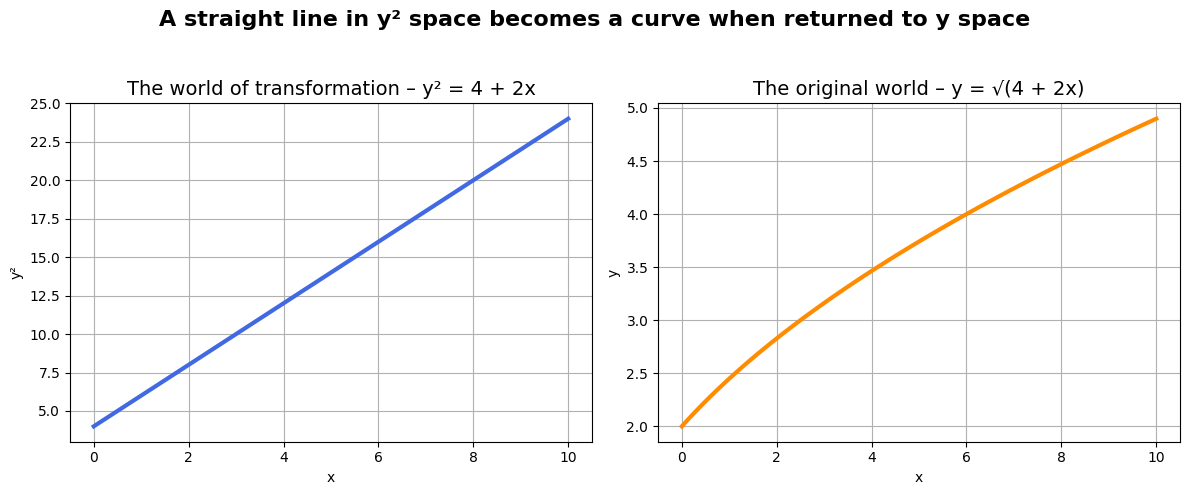

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# נתונים פשוטים להמחשה
x = np.linspace(0, 10, 100)

# מודל ליניארי על y^2
y_squared_hat = 4 + 2*x  # זה קו ישר במרחב של y^2

# החזרה לסקייל המקורי
y_hat = np.sqrt(y_squared_hat)

# גרף 1 – עולם ההתמרה (y^2)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x, y_squared_hat, color='royalblue', linewidth=3)
plt.title("The world of transformation – y² = 4 + 2x", fontsize=14)
plt.xlabel("x")
plt.ylabel("y²")
plt.grid(True)

# גרף 2 – העולם המקורי (y = √(4+2x))
plt.subplot(1,2,2)
plt.plot(x, y_hat, color='darkorange', linewidth=3)
plt.title("The original world – y = √(4 + 2x)", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)

plt.suptitle("A straight line in y² space becomes a curve when returned to y space", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


In [2]:
y_squared_hat

array([ 4.        ,  4.2020202 ,  4.4040404 ,  4.60606061,  4.80808081,
        5.01010101,  5.21212121,  5.41414141,  5.61616162,  5.81818182,
        6.02020202,  6.22222222,  6.42424242,  6.62626263,  6.82828283,
        7.03030303,  7.23232323,  7.43434343,  7.63636364,  7.83838384,
        8.04040404,  8.24242424,  8.44444444,  8.64646465,  8.84848485,
        9.05050505,  9.25252525,  9.45454545,  9.65656566,  9.85858586,
       10.06060606, 10.26262626, 10.46464646, 10.66666667, 10.86868687,
       11.07070707, 11.27272727, 11.47474747, 11.67676768, 11.87878788,
       12.08080808, 12.28282828, 12.48484848, 12.68686869, 12.88888889,
       13.09090909, 13.29292929, 13.49494949, 13.6969697 , 13.8989899 ,
       14.1010101 , 14.3030303 , 14.50505051, 14.70707071, 14.90909091,
       15.11111111, 15.31313131, 15.51515152, 15.71717172, 15.91919192,
       16.12121212, 16.32323232, 16.52525253, 16.72727273, 16.92929293,
       17.13131313, 17.33333333, 17.53535354, 17.73737374, 17.93